# 数据集预处理
针对单个数据集进行严格的：
- 设置随机种子
- 样本筛选
- 细胞质控
- 去除环境污染（是否需要？）
- 保存质控后数据至'UC/scRNA-seq_data/03_qc_filtered'文件夹
- 批次效应查看
- 降维聚类结果
- 处理异常细胞群
- 区分主要谱系

# 文件说明
- **文件名**: 8_SCP259_qc.h5ad 
- **存放位置**: 坚果云  `UC/scRNA-seq_data/03_qc_filtered/`  
- **生成日期**: 2025-11-3  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/1.2_qc_filtered/8_SCP259.ipynb  
- **内容说明**: 完成了针对单个数据的预处理工作，包括样本排除、细胞质控，并查看了样本间的批次效应。  

In [1]:
import numpy as np
import random
np.random.seed(42)
random.seed(42)

In [2]:
import scanpy as sc
sc.settings.verbosity = 1
print(sc.__version__)

1.9.6


/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_mtx from `anndata` is deprecated. Import anndata.io.read_mtx instead.
  warnings.warn(msg, FutureWarning)
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarn

## 读取数据
SCP259数据集：
- 结肠组织
- 28UC，40HC

In [3]:
adata = sc.read_h5ad('/Users/future/Nutstore Files/UC/scRNA-seq_data/02_sample_merge/8_SCP259.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 114869 × 19446
    obs: 'nGene', 'nUMI', 'Subject', 'Location', 'Sample', 'Cluster', 'Health', 'n_genes', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'features', 'n_cells', 'mt'
    uns: 'REFERENCE_MANU', 'scrublet', 'status', 'status_args'

In [5]:
adata.obs.head()

,nGene,nUMI,Subject,Location,Sample,Cluster,Health,n_genes,id,nUMIs,mito_perc,detected_genes,cell_complexity,passing_mt,passing_nUMIs,passing_ngenes,doublet_score,predicted_doublet
Fib_N10.EpiA.AACATATGGGGATG,791,1523.0,N10,Epi,N10.EpiA,WNT5B+ 2,Healthy,791,HC47,2650.122017,0.017885,791,0.298477,True,True,True,0.015040,False
Fib_N10.LPA.AAACATACTCGATG,905,2108.0,N10,LP,N10.LPA,WNT2B+ Fos-hi,Healthy,905,HC48,2772.041616,0.019755,905,0.326474,True,True,True,0.003157,False
Fib_N10.LPA.AAACGCACCTTATC,682,1435.0,N10,LP,N10.LPA,WNT2B+ Fos-lo 1,Healthy,682,HC48,2394.882939,0.021840,682,0.284774,True,True,True,0.009999,False
Fib_N10.LPA.AAACGCACTGGCAT,973,2200.0,N10,LP,N10.LPA,WNT2B+ Fos-lo 1,Healthy,973,HC48,2912.349136,0.020901,973,0.334095,True,True,True,0.006036,False
Fib_N10.LPA.AAACGCTGGTTTGG,459,752.0,N10,LP,N10.LPA,Pericytes,Healthy,459,HC48,1937.028544,0.035929,459,0.236961,True,True,True,0.087735,False


## 处理细胞标签及分组

In [6]:
# 提取分组信息
import pandas as pd
adata.obs['group'] = adata.obs['id'].str.extract(r'([A-Za-z]+)', expand=False)
print(adata.obs[['id', 'group']].head())

                               id group
Fib_N10.EpiA.AACATATGGGGATG  HC47    HC
Fib_N10.LPA.AAACATACTCGATG   HC48    HC
Fib_N10.LPA.AAACGCACCTTATC   HC48    HC
Fib_N10.LPA.AAACGCACTGGCAT   HC48    HC
Fib_N10.LPA.AAACGCTGGTTTGG   HC48    HC


In [7]:
adata.obs['GSM'] = adata.obs['Sample']

In [8]:
adata.obs.head()

,nGene,nUMI,Subject,Location,Sample,Cluster,Health,n_genes,id,nUMIs,mito_perc,detected_genes,cell_complexity,passing_mt,passing_nUMIs,passing_ngenes,doublet_score,predicted_doublet,group,GSM
Fib_N10.EpiA.AACATATGGGGATG,791,1523.0,N10,Epi,N10.EpiA,WNT5B+ 2,Healthy,791,HC47,2650.122017,0.017885,791,0.298477,True,True,True,0.015040,False,HC,N10.EpiA
Fib_N10.LPA.AAACATACTCGATG,905,2108.0,N10,LP,N10.LPA,WNT2B+ Fos-hi,Healthy,905,HC48,2772.041616,0.019755,905,0.326474,True,True,True,0.003157,False,HC,N10.LPA
Fib_N10.LPA.AAACGCACCTTATC,682,1435.0,N10,LP,N10.LPA,WNT2B+ Fos-lo 1,Healthy,682,HC48,2394.882939,0.021840,682,0.284774,True,True,True,0.009999,False,HC,N10.LPA
Fib_N10.LPA.AAACGCACTGGCAT,973,2200.0,N10,LP,N10.LPA,WNT2B+ Fos-lo 1,Healthy,973,HC48,2912.349136,0.020901,973,0.334095,True,True,True,0.006036,False,HC,N10.LPA
Fib_N10.LPA.AAACGCTGGTTTGG,459,752.0,N10,LP,N10.LPA,Pericytes,Healthy,459,HC48,1937.028544,0.035929,459,0.236961,True,True,True,0.087735,False,HC,N10.LPA


`.obs`当中只保留GSM信息和分组信息

In [9]:
adata.obs.drop(columns=['nGene', 'nUMI', 'Subject', 'Location', 'Sample', 'Cluster', 'Health', 'id'], inplace=True)
print(adata.obs.head())

                             n_genes        nUMIs  mito_perc  detected_genes  \
Fib_N10.EpiA.AACATATGGGGATG      791  2650.122017   0.017885             791   
Fib_N10.LPA.AAACATACTCGATG       905  2772.041616   0.019755             905   
Fib_N10.LPA.AAACGCACCTTATC       682  2394.882939   0.021840             682   
Fib_N10.LPA.AAACGCACTGGCAT       973  2912.349136   0.020901             973   
Fib_N10.LPA.AAACGCTGGTTTGG       459  1937.028544   0.035929             459   

                             cell_complexity  passing_mt  passing_nUMIs  \
Fib_N10.EpiA.AACATATGGGGATG         0.298477        True           True   
Fib_N10.LPA.AAACATACTCGATG          0.326474        True           True   
Fib_N10.LPA.AAACGCACCTTATC          0.284774        True           True   
Fib_N10.LPA.AAACGCACTGGCAT          0.334095        True           True   
Fib_N10.LPA.AAACGCTGGTTTGG          0.236961        True           True   

                             passing_ngenes  doublet_score  predicte

In [10]:
adata.obs['group'].value_counts()

group
HC    70029
UC    44840
Name: count, dtype: int64

## 样本质量查看

In [11]:
adata.obs['GSM'].value_counts()

GSM
N10.LPB     4899
N10.LPA     4432
N9.EpiA     4312
N10.EpiB    3794
N23.EpiA    3736
            ... 
N11.LPA      290
N12.EpiA     256
N7.EpiB      191
N8.EpiB      174
N12.EpiB      59
Name: count, Length: 68, dtype: int64

In [12]:
sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])

print(sample_quality_stats)

              n_genes                                nUMIs              \
                 mean          std  min   max         mean         std   
GSM                                                                      
N7.EpiA    515.143302   471.981460  251  3292  1746.417952  620.102220   
N7.EpiB    617.518325   580.042093  251  3950  1846.981941  672.251049   
N7.LPA     667.199400   278.271876  251  2707  1919.933194  676.093512   
N7.LPB     744.824363   382.509925  251  3099  1994.150597  657.747035   
N8.EpiA   1145.108387   873.828565  251  4378  2326.362238  840.867038   
...               ...          ...  ...   ...          ...         ...   
N23.LPB   1021.075763   557.081297  251  5354  2431.566634  660.489151   
N26.EpiA  2106.951470  1650.604079  251  7478  2692.821345  984.715479   
N26.EpiB  2174.843542  1695.465278  251  7823  2812.315527  997.171779   
N26.LPA   1237.219860   604.827484  252  5634  2453.553151  676.864736   
N26.LPB   1014.158798   496.977745  25

/var/folders/n6/ygb1nb55663b38zz1rbjx5lm0000gn/T/ipykernel_42753/2761774101.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])


## 细胞质控

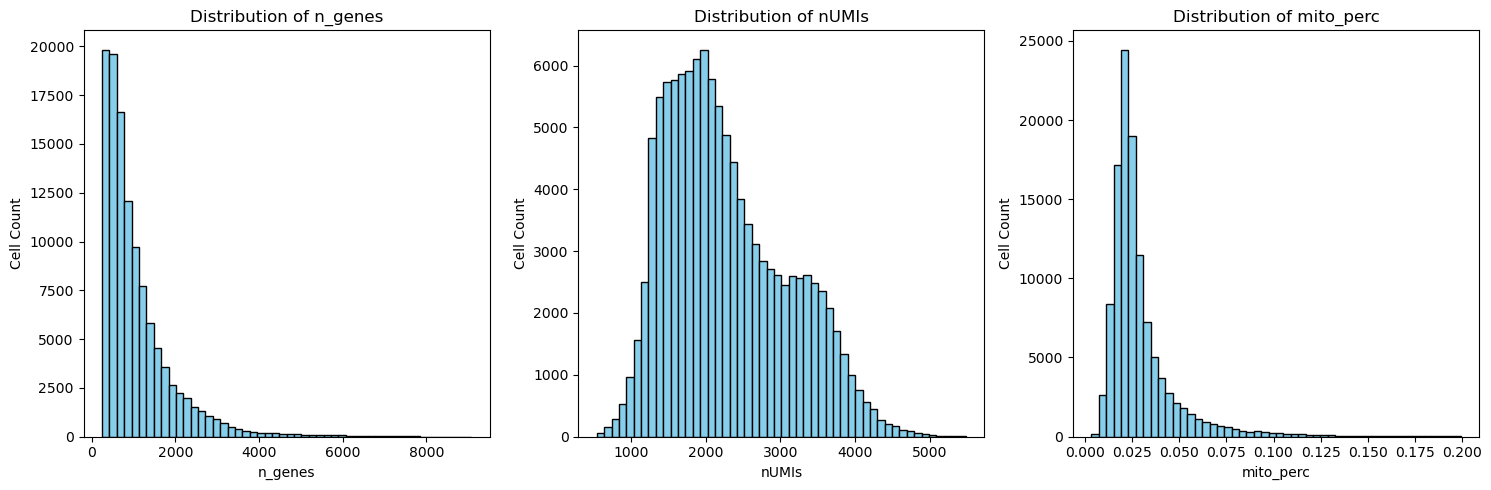

In [13]:
import matplotlib.pyplot as plt

# 选择要可视化的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 绘制各个指标的直方图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# 绘制每个质量控制指标的直方图
for i, metric in enumerate(qc_metrics):
    ax[i].hist(adata.obs[metric], bins=50, color='skyblue', edgecolor='black')
    ax[i].set_title(f'Distribution of {metric}')
    ax[i].set_xlabel(metric)
    ax[i].set_ylabel('Cell Count')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/var/folders/n6/ygb1nb55663b38zz1rbjx5lm0000gn/T/ipykernel_42753/2077234365.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels, rotation=45, ha='right')
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

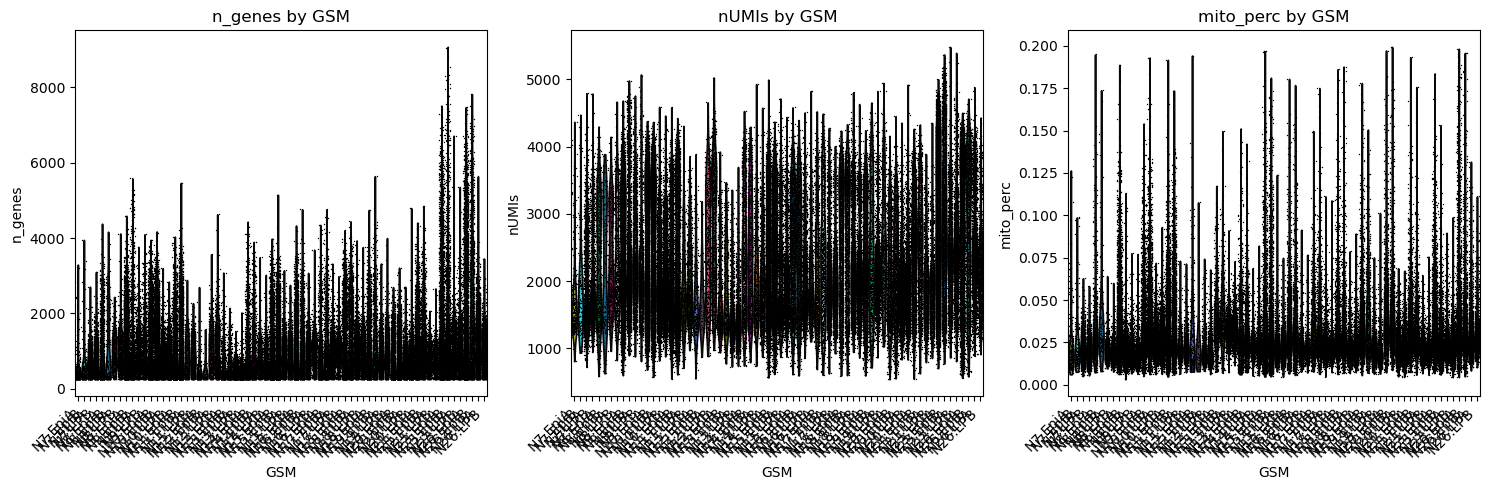

In [14]:
# 设置绘图风格
sc.settings.verbosity = 0  # 简化日志输出

# 选择要绘制的小提琴图的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 按照样本（GSM）绘制小提琴图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(qc_metrics):
    sc.pl.violin(adata, keys=metric, groupby='GSM', ax=ax[i], stripplot=True, jitter=0.4, show=False)
    ax[i].set_title(f'{metric} by GSM')
    ax[i].set_ylabel(f'{metric}')
    
    # 获取当前的x轴标签
    labels = ax[i].get_xticklabels()
    # 旋转标签并调整对齐方式（末尾对齐）
    ax[i].set_xticklabels(labels, rotation=45, ha='right')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


### 严格细胞质控标准
- min_genes = 200          # 最少基因数
- max_genes = 4000         # 最多基因数
- min_umis = 500           # 最少UMI数量
- max_umis = 20000         # 最多UMI数量
- max_mito_perc = 10       # 线粒体基因百分比最大值

In [15]:
# 设置阈值
min_genes = 200          # 最少基因数
max_genes = 6000         # 最多基因数
min_umis = 500           # 最少UMI数量
max_umis = 20000        # 最多UMI数量
max_mito_perc = 0.1       # 线粒体基因百分比最大值

# 根据阈值进行过滤
adata = adata[(adata.obs['n_genes'] > min_genes) & 
              (adata.obs['n_genes'] < max_genes) &
              (adata.obs['nUMIs'] > min_umis) &
              (adata.obs['nUMIs'] < max_umis) &
              (adata.obs['mito_perc'] < max_mito_perc), :]

# 输出过滤后的细胞数
print(f'Number of cells after filtering: {adata.n_obs}')

Number of cells after filtering: 113095


## 保存质控后数据


In [16]:
import os
output_dir = "/Users/future/Nutstore Files/UC/scRNA-seq_data/03_qc_filtered/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "8_SCP259_qc.h5ad"), compression='gzip')

## 降维聚类

In [ ]:
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

血液组织细胞，所以选取2000个高变基因  
大致分别谱系，所以选取resolution=0.4

In [ ]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.4)

In [ ]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

In [ ]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

## 去除批次效应
按样本去除批次，看看是否效果会更好

使用`harmony`

In [ ]:
ov.single.batch_correction(adata,
                           batch_key='GSM', # 去批次分组标签
                           methods='harmony',
                           n_pcs=50)
                           
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='X_harmony')

ov.pp.umap(adata)

ov.pp.leiden(adata,resolution=0.4)

In [ ]:
# 可视化查看去除批次效应后聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.5)

In [ ]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

## GPT自动注释

In [ ]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

In [ ]:
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='colon',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

In [ ]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

In [ ]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [ ]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)